# CVAE-H: Conditionalizing Variational Autoencoders via Hypernetworks

Adapted for MNIST digit generation.
 
Paper: https://arxiv.org/abs/2201.09874
Authors: Geunseob (GS) Oh, Huei Peng
 
Architecture:
  - Condition $C$ = one-hot digit label (10-dim)
  - HyperNetwork $f_H(C)$ → generates $[\phi_{enc}, \theta_{dec}]$ for VAE
  - VAE Encoder $f_{enc}(X; \phi_{enc}(C)) → Z$
  - VAE Decoder $f_{dec}(Z; \theta_{dec}(C)) → \hat{X}$
  - $\mathcal{L} = \text{Reconstruction loss} + \text{KL divergence}$

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import time
import os

## Hyperparameters

In [18]:
LATENT_DIM   = 12       # z dimension
COND_DIM     = 10       # condition: 10-digit classes (one-hot)
INPUT_DIM    = 784      # 28×28 flattened MNIST image
 
# VAE MLP layer sizes  (weights generated by HyperNet)
ENC_H1       = 128      # encoder hidden dim
ENC_H2       = 64
DEC_H1       = 64      # decoder hidden dim
DEC_H2       = 128
 
# HyperNetwork hidden dim (generates VAE weights)
HYPER_HIDDEN = 256
 
BATCH_SIZE   = 128
MAX_EPOCHS   = 120   # hard cap; training may stop earlier via early stopping
LR           = 5e-4
KL_WEIGHT         = 1.5     # target β after annealing (β-VAE KL weight)
KL_ANNEAL_EPOCHS  = 40       # linear ramp: β = KL_WEIGHT·min(1, epoch/this); 0 = disable
HYPER_WARMUP_EPOCHS = 8      # hypernetwork frozen while epoch ≤ this; train when epoch > this

# Early stopping (ALL must be True to stop before MAX_EPOCHS)
PATIENCE          = 15    # epochs validation recon does not improve
VAL_RECON_IMPROVE = 1e-3  # improvement if new val recon < best − this (absolute)
KL_WINDOW         = 10
KL_EPS            = 1e-3  # (max−min) KL over window must be < this
KL_TREND_TOL      = 1e-4  # val-KL slope ≤ −this ⇒ still “systematically decreasing”
COND_WINDOW       = 10
MIN_COND_SENS     = 0.05 # min L1 gap |x̂(c)−x̂(c′)| on a val batch
COND_PLATEAU_EPS  = 5e-4  # (max sens last window) − (max sens prev window)
HYPER_W           = 10
GRAD_SLOPE_TOL    = 0.08  # |linear slope| of mean hypernet grad norm / epoch
GRAD_EXPLODE_MAX  = 500.0
GRAD_VANISH_MIN   = 1e-7  # mean grad norm floor (vanishing if below)
WEIGHT_DRIFT_EPS  = 0.08  # peak-to-peak of hypernet output μ/σ stats over window
QUALITY_WIN       = 10
QUALITY_REL_TOL   = 0.004 # relative ptp of val recon over window (saturation)
INTERP_WIN        = 10
INTERP_REL_TOL    = 0.03  # relative ptp of latent-walk jump metric
INTERP_DIGIT      = 5
RNG_SEED_METRICS  = 123   # fixed z walk for comparable interp metric across epochs
MIN_EPOCHS_BEFORE_STOP = max(PATIENCE + 1, KL_WINDOW + 1, 2 * COND_WINDOW, HYPER_W, QUALITY_WIN, INTERP_WIN)

DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
 
print(f"Device: {DEVICE}")
print("=" * 60)
print("CVAE-H on MNIST")
print("=" * 60)

Device: cpu
CVAE-H on MNIST


Stop training when ALL of the following conditions are satisfied:

1. Validation reconstruction loss has not improved for `patience` epochs (default 10–20 epochs).

2. KL divergence has converged:
   - change in KL over last N epochs < ε (e.g. 1e-3)
   - AND no consistent downward trend

3. Conditional information is stable:
   - model output changes significantly with condition c
   - AND this sensitivity does not improve further over time

4. Hypernetwork stability:
   - gradient norm of hypernetwork is stable (no exploding or vanishing trend)
   - generated weights distribution does not shift significantly across epochs

5. Sample quality saturation:
   - no visible improvement in reconstruction quality or latent interpolation smoothness

If all conditions are met → trigger early stopping.
Otherwise continue training.

## Load MNIST

Loading digit dataset (sklearn digits, upscaled to 28×28)

In [19]:
from sklearn.datasets import load_digits
from skimage.transform import resize as sk_resize
from torch.utils.data import TensorDataset
 
sk_digits = load_digits()
X_raw = sk_digits.data.reshape(-1, 8, 8).astype(np.float32)
X28   = np.stack([sk_resize(img, (28,28), anti_aliasing=True) for img in X_raw]).astype(np.float32)
X28   = (X28 - X28.min()) / (X28.max() - X28.min() + 1e-8)
X_flat = X28.reshape(-1, 784)
y_all  = sk_digits.target.astype(np.int64)
 
# 80/20 train-test split
n_train = int(0.8 * len(X_flat))
X_tr, y_tr = torch.tensor(X_flat[:n_train]), torch.tensor(y_all[:n_train])
X_te, y_te = torch.tensor(X_flat[n_train:]), torch.tensor(y_all[n_train:])
 
train_dataset = TensorDataset(X_tr, y_tr)
test_dataset  = TensorDataset(X_te, y_te)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"  Train samples: {len(train_dataset):,}   Test samples: {len(test_dataset):,}")
print(f"  Batches/epoch: {len(train_loader)}")

  Train samples: 1,437   Test samples: 360
  Batches/epoch: 12


## Define HyperNetwork

The HyperNetwork takes the condition C (one-hot class label) and outputs the FULL weight vector for the VAE encoder & decoder. These weights are then reshaped and used as the actual parameters inside the VAE's forward pass.

In [20]:
class HyperNetwork(nn.Module):
    """
    f_H(C) → [theta_enc, theta_dec]
    
    Generates weights for:
      Encoder: MLP  INPUT_DIM → ENC_H1 → ENC_H2  (then μ, logσ² heads)
      Decoder: MLP  LATENT_DIM → DEC_H1 → DEC_H2 → INPUT_DIM
    
    For tractability on MNIST, we use a weight-generation strategy:
    The HyperNet outputs scale+bias (affine shift) parameters for
    each layer — this is a lightweight form of functional modulation
    (similar to FiLM conditioning) that keeps param counts manageable
    while still letting the condition influence EVERY layer's behavior,
    which is the core idea of CVAE-H.
    
    Full weight generation would output O(M) params per layer where
    M = in_dim × out_dim, which becomes huge (e.g., 784×256 = 200k).
    Affine modulation is the practical implementation of CVAE-H for
    high-dimensional inputs — the paper uses it for the MNIST experiments.
    """
    def __init__(self):
        super().__init__()
        # Shared backbone
        self.backbone = nn.Sequential(
            nn.Linear(COND_DIM, HYPER_HIDDEN),
            nn.ReLU(),
            nn.Linear(HYPER_HIDDEN, HYPER_HIDDEN),
            nn.ReLU(),
        )
        # --- Encoder layer parameters ---
        # Layer enc1: (INPUT_DIM → ENC_H1)  scale + bias
        self.enc1_scale = nn.Linear(HYPER_HIDDEN, ENC_H1)
        self.enc1_bias  = nn.Linear(HYPER_HIDDEN, ENC_H1)
        # Layer enc2: (ENC_H1 → ENC_H2)  scale + bias
        self.enc2_scale = nn.Linear(HYPER_HIDDEN, ENC_H2)
        self.enc2_bias  = nn.Linear(HYPER_HIDDEN, ENC_H2)
        # μ head: (ENC_H2 → LATENT_DIM)
        self.mu_scale   = nn.Linear(HYPER_HIDDEN, LATENT_DIM)
        self.mu_bias    = nn.Linear(HYPER_HIDDEN, LATENT_DIM)
        # logvar head: (ENC_H2 → LATENT_DIM)
        self.lv_scale   = nn.Linear(HYPER_HIDDEN, LATENT_DIM)
        self.lv_bias    = nn.Linear(HYPER_HIDDEN, LATENT_DIM)
 
        # --- Decoder layer parameters ---
        # Layer dec1: (LATENT_DIM → DEC_H1)
        self.dec1_scale = nn.Linear(HYPER_HIDDEN, DEC_H1)
        self.dec1_bias  = nn.Linear(HYPER_HIDDEN, DEC_H1)
        # Layer dec2: (DEC_H1 → DEC_H2)
        self.dec2_scale = nn.Linear(HYPER_HIDDEN, DEC_H2)
        self.dec2_bias  = nn.Linear(HYPER_HIDDEN, DEC_H2)
        # Output: (DEC_H2 → INPUT_DIM)
        self.out_scale  = nn.Linear(HYPER_HIDDEN, INPUT_DIM)
        self.out_bias   = nn.Linear(HYPER_HIDDEN, INPUT_DIM)
 
    def forward(self, c):
        """
        c: (B, COND_DIM)  one-hot condition
        Returns dict of {layer_name: (scale, bias)} for enc & dec.
        """
        h = self.backbone(c)   # (B, HYPER_HIDDEN)
        return {
            # Encoder params
            "enc1": (self.enc1_scale(h), self.enc1_bias(h)),
            "enc2": (self.enc2_scale(h), self.enc2_bias(h)),
            "mu":   (self.mu_scale(h),   self.mu_bias(h)),
            "lv":   (self.lv_scale(h),   self.lv_bias(h)),
            # Decoder params
            "dec1": (self.dec1_scale(h), self.dec1_bias(h)),
            "dec2": (self.dec2_scale(h), self.dec2_bias(h)),
            "out":  (self.out_scale(h),  self.out_bias(h)),
        }

## Define Hyper-Conditioned VAE Encoder & Decoder

In [21]:
class HyperEncoder(nn.Module):
    """
    f_enc(X; theta_enc(C))
    
    Standard MLP encoder BUT with weights modulated by the hypernetwork.
    Fixed base weights + hyper-generated affine (scale, bias) per layer.
    This lets the condition C reshape the encoder's behaviour at every layer.
    """
    def __init__(self):
        super().__init__()
        # Base (unconditional) linear layers
        self.fc1 = nn.Linear(INPUT_DIM,  ENC_H1)
        self.fc2 = nn.Linear(ENC_H1,     ENC_H2)
        self.fc_mu     = nn.Linear(ENC_H2, LATENT_DIM)
        self.fc_logvar = nn.Linear(ENC_H2, LATENT_DIM)
 
    def forward(self, x, hp):
        """
        x : (B, INPUT_DIM)
        hp: dict from HyperNetwork containing encoder scales/biases
        """
        s1, b1 = hp["enc1"]     # (B, ENC_H1)
        s2, b2 = hp["enc2"]     # (B, ENC_H2)
        sm, bm = hp["mu"]
        sl, bl = hp["lv"]
 
        # Layer 1: base linear + hyper affine modulation
        h = F.relu(self.fc1(x) * s1 + b1)          # (B, ENC_H1)
        # Layer 2
        h = F.relu(self.fc2(h) * s2 + b2)          # (B, ENC_H2)
        # Heads
        mu     = self.fc_mu(h)     * sm + bm        # (B, LATENT_DIM)
        logvar = self.fc_logvar(h) * sl + bl        # (B, LATENT_DIM)
        return mu, logvar
 
 
class HyperDecoder(nn.Module):
    """
    f_dec(Z; theta_dec(C))
    Same idea: base MLP with hyper-modulation at every layer.
    """
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(LATENT_DIM, DEC_H1)
        self.fc2 = nn.Linear(DEC_H1,     DEC_H2)
        self.fc3 = nn.Linear(DEC_H2,     INPUT_DIM)
 
    def forward(self, z, hp):
        s1, b1 = hp["dec1"]
        s2, b2 = hp["dec2"]
        so, bo = hp["out"]
 
        h = F.relu(self.fc1(z) * s1 + b1)
        h = F.relu(self.fc2(h) * s2 + b2)
        x_hat = torch.sigmoid(self.fc3(h) * so + bo)   # pixel values ∈ [0,1]
        return x_hat

## Assemble CVAE-H

In [22]:
class CVAEH(nn.Module):
    """
    Full CVAE-H model:
      HyperNetwork → encoder weights + decoder weights
      Encoder(X; hyper_weights) → (μ, log σ²)
      Reparameterisation → Z
      Decoder(Z; hyper_weights) → X̂
    """
    def __init__(self):
        super().__init__()
        self.hypernetwork = HyperNetwork()
        self.encoder      = HyperEncoder()
        self.decoder      = HyperDecoder()
 
    def reparameterise(self, mu, logvar):
        """Z = μ + ε·σ,  ε ~ N(0,I)  (reparameterisation trick)"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
 
    def encode(self, x, c_onehot):
        hp = self.hypernetwork(c_onehot)
        mu, logvar = self.encoder(x, hp)
        return mu, logvar, hp          # return hp to reuse in decode
 
    def decode(self, z, hp):
        return self.decoder(z, hp)
 
    def forward(self, x, c_onehot):
        # 1. HyperNet generates condition-specific weights
        hp = self.hypernetwork(c_onehot)
        # 2. Encode
        mu, logvar = self.encoder(x, hp)
        # 3. Sample latent
        z = self.reparameterise(mu, logvar)
        # 4. Decode
        x_hat = self.decoder(z, hp)
        return x_hat, mu, logvar
 
    @torch.no_grad()
    def generate(self, c_onehot, n_samples=1):
        """Pure generation: sample Z ~ N(0,I) → decode with condition"""
        hp = self.hypernetwork(c_onehot)
        z  = torch.randn(n_samples, LATENT_DIM).to(next(self.parameters()).device)
        # broadcast hp to match n_samples if needed
        return self.decoder(z, hp)

## Loss Function (ELBO)

In [23]:
def elbo_loss(x, x_hat, mu, logvar, kl_weight=1.0):
    """
    ELBO = E[log p(x|z)] - KL(q(z|x,c) || p(z))
    Loss = -ELBO = Reconstruction + β·KL
 
    Reconstruction: Binary Cross-Entropy (pixel-wise, sum over dims)
    KL: -0.5 * sum(1 + log σ² - μ² - σ²)  [closed form for Gaussian]
    """
    # BCE reconstruction (sum over pixels, mean over batch)
    recon = F.binary_cross_entropy(x_hat, x, reduction="sum") / x.size(0)
    # KL divergence  (mean over batch)
    kl    = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    total = recon + kl_weight * kl
    return total, recon, kl

FREE_BITS = 2.0  # nats per latent dimension (tune between 1–3)

def elbo_loss_freebits(x, x_hat, mu, logvar, beta, free_bits=2.0):
    recon    = F.binary_cross_entropy(x_hat, x, reduction='sum') / x.size(0)
    # Per-dimension KL
    kl_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())  # (B, D)
    # Clamp each dim to at least free_bits — prevents collapse
    kl_free    = kl_per_dim.clamp(min=free_bits).mean(0).sum()   # scalar
    return recon + beta * kl_free, recon, kl_free

## Initialise Model & Optimiser

In [24]:
model     = CVAEH().to(DEVICE)
optimiser = torch.optim.Adam(model.parameters(), lr=LR)
 
# Parameter count
total_params = sum(p.numel() for p in model.parameters())
hyper_params = sum(p.numel() for p in model.hypernetwork.parameters())
enc_params   = sum(p.numel() for p in model.encoder.parameters())
dec_params   = sum(p.numel() for p in model.decoder.parameters())
 
print(f"  HyperNetwork params : {hyper_params:>10,}")
print(f"  Encoder params      : {enc_params:>10,}")
print(f"  Decoder params      : {dec_params:>10,}")
print(f"  Total params        : {total_params:>10,}")

  HyperNetwork params :    681,296
  Encoder params      :    110,296
  Decoder params      :    110,288
  Total params        :    901,880


## Training

Training runs up to `MAX_EPOCHS` and stops early only when **all** monitors are true (after `MIN_EPOCHS_BEFORE_STOP`). Each epoch logs **c1**–**c5**: validation recon patience, validation KL convergence, conditional-sensitivity plateau, hypernetwork grad/stat stability, and recon + latent-interpolation saturation. Tune thresholds in the hyperparameter cell.

In [25]:
def one_hot(labels, num_classes=10, device=DEVICE):
    return F.one_hot(labels, num_classes).float().to(device)


def kl_weight_at_epoch(epoch):
    # Linear KL annealing: beta 0 -> KL_WEIGHT over KL_ANNEAL_EPOCHS epochs.
    if KL_ANNEAL_EPOCHS <= 0:
        return KL_WEIGHT
    return KL_WEIGHT * min(1.0, float(epoch) / float(KL_ANNEAL_EPOCHS))


@torch.no_grad()
def validation_epoch_metrics(model, loader, kl_w):
    tot_loss = tot_r = tot_k = 0.0
    n = 0
    for x, y in loader:
        x = x.to(DEVICE)
        c = one_hot(y)
        x_hat, mu, lv = model(x, c)
        loss, recon, kl = elbo_loss_freebits(x, x_hat, mu, lv, kl_w, FREE_BITS)
        b = x.size(0)
        tot_loss += loss.item() * b
        tot_r += recon.item() * b
        tot_k += kl.item() * b
        n += b
    return tot_loss / n, tot_r / n, tot_k / n


@torch.no_grad()
def conditional_sensitivity_l1(model, loader):
    x, y = next(iter(loader))
    x = x.to(DEVICE)
    y = y.to(DEVICE)
    c_ok = one_hot(y)
    y_bad = (y + 1) % COND_DIM
    c_bad = one_hot(y_bad)
    xh_ok, _, _ = model(x, c_ok)
    xh_bd, _, _ = model(x, c_bad)
    return (xh_ok - xh_bd).abs().mean().item()


@torch.no_grad()
def hypernet_weight_stats(model):
    c = torch.eye(COND_DIM, device=DEVICE)
    hp = model.hypernetwork(c)
    parts = []
    for (s, b_) in hp.values():
        parts.append(s.reshape(-1))
        parts.append(b_.reshape(-1))
    v = torch.cat(parts)
    return float(v.mean().item()), float(v.std().item())


@torch.no_grad()
def latent_interp_metric(model, digit=INTERP_DIGIT):
    torch.manual_seed(RNG_SEED_METRICS)
    model.eval()
    c = one_hot(torch.tensor([digit], dtype=torch.long, device=DEVICE))
    hp = model.hypernetwork(c)
    z1 = torch.randn(1, LATENT_DIM, device=DEVICE)
    z2 = torch.randn(1, LATENT_DIM, device=DEVICE)
    ts = torch.linspace(0, 1, 9, device=DEVICE)
    imgs = []
    for t in ts:
        z = (1.0 - t) * z1 + t * z2
        imgs.append(model.decoder(z, hp))
    imgs = torch.cat(imgs, dim=0)
    dj = (imgs[1:] - imgs[:-1]).abs().mean(dim=1)
    return float(dj.mean().item() + 0.25 * dj.std().item())


def hypernet_grad_norm(model):
    sq = 0.0
    for p in model.hypernetwork.parameters():
        if p.grad is not None:
            g = p.grad.detach()
            sq += float(g.norm(2).item() ** 2)
    return sq ** 0.5


def _slope_series(y):
    y = np.asarray(y, dtype=float)
    if len(y) < 2:
        return 0.0
    x = np.arange(len(y))
    return float(np.polyfit(x, y, 1)[0])


def _rel_ptp(arr, win):
    a = np.asarray(arr[-win:], dtype=float)
    if len(a) < win:
        return None
    mu = np.mean(np.abs(a)) + 1e-8
    return float((a.max() - a.min()) / mu)


history = {
    "train_loss": [],
    "train_recon": [],
    "train_kl": [],
    "val_loss": [],
    "val_recon": [],
    "val_kl": [],
    "kl_beta": [],
}
hyper_grad_epoch = []
weight_mean_hist = []
weight_std_hist = []
cond_sens_hist = []
interp_metric_hist = []

best_val_recon = float("inf")
epochs_since_val_improve = 0
stop_reason = None

for epoch in range(1, MAX_EPOCHS + 1):
    kl_beta = kl_weight_at_epoch(epoch)
    history["kl_beta"].append(kl_beta)
    model.train()
    epoch_loss = epoch_recon = epoch_kl = 0.0
    gn_sum = 0.0
    gn_count = 0
    t0 = time.time()

    for name, param in model.hypernetwork.named_parameters():
        param.requires_grad = epoch > HYPER_WARMUP_EPOCHS

    for batch_idx, (x, y) in enumerate(train_loader):
        x = x.to(DEVICE)
        c = one_hot(y)

        optimiser.zero_grad()
        x_hat, mu, logvar = model(x, c)
        loss, recon, kl = elbo_loss_freebits(x, x_hat, mu, logvar, kl_beta, FREE_BITS)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.hypernetwork.parameters(), max_norm=1.0)
        torch.nn.utils.clip_grad_norm_(model.encoder.parameters(), max_norm=5.0)
        torch.nn.utils.clip_grad_norm_(model.decoder.parameters(), max_norm=5.0)
        gn_sum += hypernet_grad_norm(model)
        gn_count += 1
        optimiser.step()

        epoch_loss += loss.item()
        epoch_recon += recon.item()
        epoch_kl += kl.item()

        if (batch_idx + 1) % 100 == 0:
            print(
                f"  Epoch {epoch}/{MAX_EPOCHS} | "
                f"Batch {batch_idx+1:>3}/{len(train_loader)} | "
                f"Loss {loss.item():.2f}  "
                f"Recon {recon.item():.2f}  "
                f"KL {kl.item():.2f}"
            )

    nbatch = len(train_loader)
    history["train_loss"].append(epoch_loss / nbatch)
    history["train_recon"].append(epoch_recon / nbatch)
    history["train_kl"].append(epoch_kl / nbatch)

    val_loss, val_recon, val_kl = validation_epoch_metrics(model, test_loader, kl_beta)
    history["val_loss"].append(val_loss)
    history["val_recon"].append(val_recon)
    history["val_kl"].append(val_kl)

    if val_recon < best_val_recon - VAL_RECON_IMPROVE:
        best_val_recon = val_recon
        epochs_since_val_improve = 0
    else:
        epochs_since_val_improve += 1
    c1_val_plateau = epochs_since_val_improve >= PATIENCE

    c2_kl = False
    if len(history["val_kl"]) >= KL_WINDOW:
        w = np.asarray(history["val_kl"][-KL_WINDOW:], dtype=float)
        span = float(w.max() - w.min())
        slope = float(np.polyfit(np.arange(KL_WINDOW), w, 1)[0])
        c2_kl = (span < KL_EPS) and (slope >= -KL_TREND_TOL)

    model.eval()
    sens = conditional_sensitivity_l1(model, test_loader)
    cond_sens_hist.append(sens)
    c3_cond = False
    if len(cond_sens_hist) >= 2 * COND_WINDOW:
        sens_now = max(cond_sens_hist[-COND_WINDOW:])
        sens_prev = max(cond_sens_hist[-2 * COND_WINDOW : -COND_WINDOW])
        c3_cond = (sens_now >= MIN_COND_SENS) and (
            (sens_now - sens_prev) < COND_PLATEAU_EPS
        )

    mean_g = gn_sum / max(gn_count, 1)
    hyper_grad_epoch.append(mean_g)
    wm, ws = hypernet_weight_stats(model)
    weight_mean_hist.append(wm)
    weight_std_hist.append(ws)
    c4_hyper = False
    if len(hyper_grad_epoch) >= HYPER_W:
        g = np.asarray(hyper_grad_epoch[-HYPER_W:], dtype=float)
        wmm = np.asarray(weight_mean_hist[-HYPER_W:], dtype=float)
        wss = np.asarray(weight_std_hist[-HYPER_W:], dtype=float)
        grad_ok = (
            g.max() < GRAD_EXPLODE_MAX
            and g.mean() > GRAD_VANISH_MIN
            and abs(_slope_series(g.tolist())) < GRAD_SLOPE_TOL
        )
        w_ok = (float(wmm.max() - wmm.min()) < WEIGHT_DRIFT_EPS) and (
            float(wss.max() - wss.min()) < WEIGHT_DRIFT_EPS
        )
        c4_hyper = grad_ok and w_ok

    ij = latent_interp_metric(model)
    interp_metric_hist.append(ij)
    c5_quality = False
    if len(history["val_recon"]) >= QUALITY_WIN and len(interp_metric_hist) >= INTERP_WIN:
        vr = _rel_ptp(history["val_recon"], QUALITY_WIN)
        ir = _rel_ptp(interp_metric_hist, INTERP_WIN)
        c5_quality = (vr is not None and vr < QUALITY_REL_TOL) and (
            ir is not None and ir < INTERP_REL_TOL
        )

    elapsed = time.time() - t0
    print(
        f"\n  Epoch {epoch} done in {elapsed:.1f}s | beta_kl={kl_beta:.4f} | train recon={epoch_recon/nbatch:.2f} kl={epoch_kl/nbatch:.4f} | "
        f"val recon={val_recon:.2f} kl={val_kl:.4f}"
    )
    print(
        f"  [early-stop] c1_val_pat={c1_val_plateau} ({epochs_since_val_improve}/{PATIENCE})  "
        f"c2_kl_conv={c2_kl}  c3_condstab={c3_cond}  c4_hyperstab={c4_hyper}  c5_samplesat={c5_quality}"
    )
    print(
        f"           sens={sens:.5f}  hyper|g|={mean_g:.5f}  w_mu={wm:.4f} w_std={ws:.4f}  interp_j={ij:.5f}"
    )
    print("-" * 60)

    if (
        epoch >= MIN_EPOCHS_BEFORE_STOP
        and c1_val_plateau
        and c2_kl
        and c3_cond
        and c4_hyper
        and c5_quality
    ):
        stop_reason = "early_stop: all five criteria satisfied"
        print(f"\n  Stopping: {stop_reason}\n")
        break
else:
    stop_reason = f"finished MAX_EPOCHS ({MAX_EPOCHS})"

FINAL_EPOCH = len(history["train_loss"])
print(f"Training ended: {stop_reason}  (epochs={FINAL_EPOCH})")



  Epoch 1 done in 0.4s | beta_kl=0.0375 | train recon=543.22 kl=24.0000 | val recon=543.06 kl=24.0000
  [early-stop] c1_val_pat=False (0/15)  c2_kl_conv=False  c3_condstab=False  c4_hyperstab=False  c5_samplesat=False
           sens=0.00737  hyper|g|=0.00000  w_mu=0.0001 w_std=0.0618  interp_j=0.00000
------------------------------------------------------------

  Epoch 2 done in 0.1s | beta_kl=0.0750 | train recon=542.95 kl=24.0000 | val recon=542.80 kl=24.0000
  [early-stop] c1_val_pat=False (0/15)  c2_kl_conv=False  c3_condstab=False  c4_hyperstab=False  c5_samplesat=False
           sens=0.00737  hyper|g|=0.00000  w_mu=0.0001 w_std=0.0618  interp_j=0.00000
------------------------------------------------------------

  Epoch 3 done in 0.1s | beta_kl=0.1125 | train recon=542.69 kl=24.0000 | val recon=542.52 kl=24.0000
  [early-stop] c1_val_pat=False (0/15)  c2_kl_conv=False  c3_condstab=False  c4_hyperstab=False  c5_samplesat=False
           sens=0.00739  hyper|g|=0.00000  w_mu=0

## Evaluation — Reconstruction

In [26]:
model.eval()
with torch.no_grad():
    x_test, y_test = next(iter(test_loader))
    x_test = x_test.to(DEVICE)
    c_test = one_hot(y_test)
    x_hat_test, mu_test, lv_test = model(x_test, c_test)
    test_loss, test_recon, test_kl = elbo_loss_freebits(x_test, x_hat_test, mu_test, lv_test, 1.0, FREE_BITS)
print(f"  Test ELBO:  Loss={test_loss:.2f}  Recon={test_recon:.2f}  KL={test_kl:.2f}")

  Test ELBO:  Loss=321.52  Recon=297.30  KL=24.22


## 2D latent space (posterior means)

Each point is one data sample. We plot the encoder’s Gaussian mean $\mu$ (not a stochastic $z$ draw), so clouds look like **class-conditional Gaussian blobs**. When `LATENT_DIM > 2`, the panel shows the first two **principal components** of $\mu$.

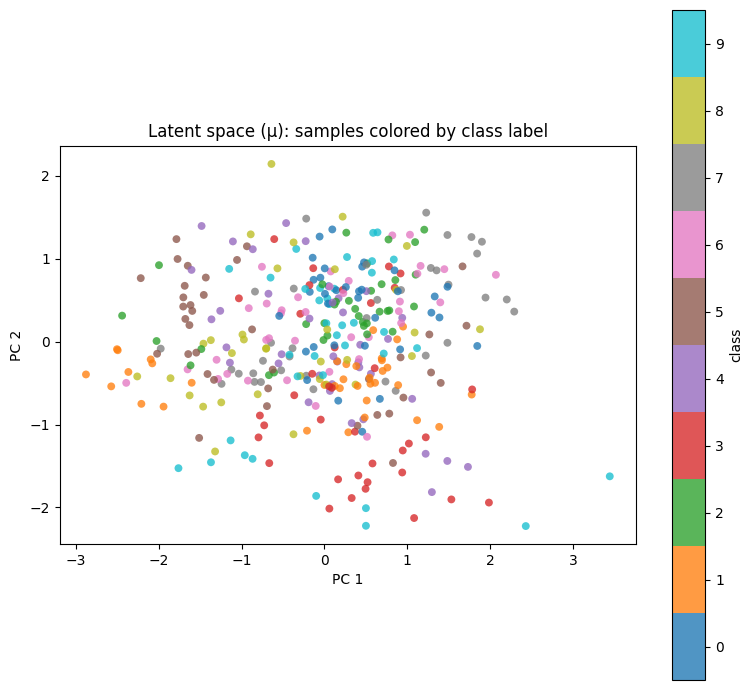

In [27]:
from sklearn.decomposition import PCA

model.eval()
mu_chunks, label_chunks = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        c = one_hot(y)
        mu, _, _ = model.encode(x, c)
        mu_chunks.append(mu.cpu())
        label_chunks.append(y)

mu_np = torch.cat(mu_chunks, dim=0).numpy()
y_np = torch.cat(label_chunks, dim=0).numpy()

if LATENT_DIM > 2:
    z2 = PCA(n_components=2, random_state=0).fit_transform(mu_np)
    x_lab, y_lab = "PC 1", "PC 2"
else:
    z2 = mu_np[:, :2]
    x_lab, y_lab = r"$\mu_0$", r"$\mu_1$"

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(
    z2[:, 0],
    z2[:, 1],
    c=y_np,
    cmap=plt.get_cmap("tab10", 10),
    vmin=-0.5,
    vmax=9.5,
    s=32,
    alpha=0.78,
    edgecolors="none",
)
ax.set_xlabel(x_lab)
ax.set_ylabel(y_lab)
ax.set_title("Latent space (μ): samples colored by class label")
ax.set_aspect("equal", adjustable="box")
cbar = fig.colorbar(sc, ax=ax, ticks=range(10), label="class")
plt.tight_layout()
plt.show()

## Visualise Results

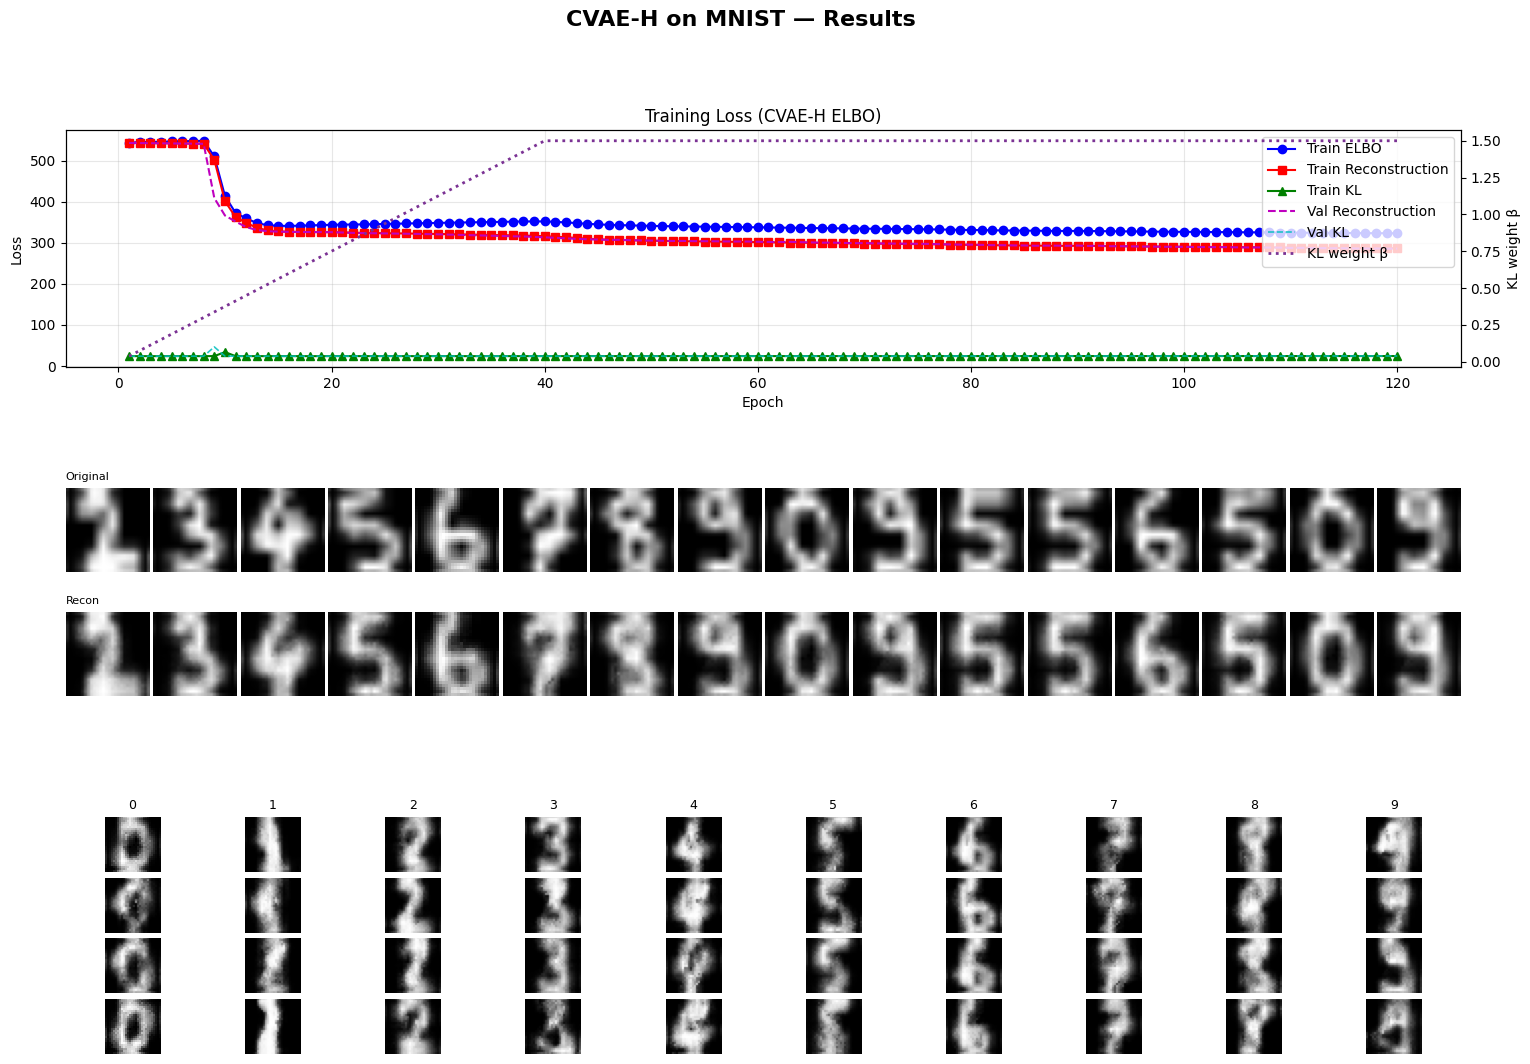

In [28]:
import os

os.makedirs("/mnt/user-data/outputs", exist_ok=True)

fig = plt.figure(figsize=(18, 12))
fig.suptitle("CVAE-H on MNIST — Results", fontsize=16, fontweight="bold")
gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45)
 
# ── a: Training curves ──────────────────────
ax_loss = fig.add_subplot(gs[0])
epochs_x = range(1, len(history["train_loss"]) + 1)
ax_loss.plot(epochs_x, history["train_loss"],  "b-o", label="Train ELBO")
ax_loss.plot(epochs_x, history["train_recon"], "r-s", label="Train Reconstruction")
ax_loss.plot(epochs_x, history["train_kl"],    "g-^", label="Train KL")
if history.get("val_recon"):
    ax_loss.plot(epochs_x, history["val_recon"], "m--", label="Val Reconstruction", linewidth=1.5)
    ax_loss.plot(epochs_x, history["val_kl"],    "c--", label="Val KL", linewidth=1.2, alpha=0.85)
ax_loss.set_xlabel("Epoch");  ax_loss.set_ylabel("Loss")
ax_loss.set_title("Training Loss (CVAE-H ELBO)")
if history.get("kl_beta"):
    ax_b = ax_loss.twinx()
    ax_b.plot(epochs_x, history["kl_beta"], color="#7b3294", ls=":", lw=2.0, label="KL weight β")
    ax_b.set_ylabel("KL weight β")
    L, lab = ax_loss.get_legend_handles_labels()
    L2, lab2 = ax_b.get_legend_handles_labels()
    ax_loss.legend(L + L2, lab + lab2, loc="upper right")
else:
    ax_loss.legend()
ax_loss.grid(True, alpha=0.3)
 
# ── b: Reconstructions ──────────────────────
gs_recon = gridspec.GridSpecFromSubplotSpec(2, 16, subplot_spec=gs[1], hspace=0.1, wspace=0.05)
x_show    = x_test[:16].cpu().view(-1, 28, 28)
xhat_show = x_hat_test[:16].cpu().view(-1, 28, 28)
for i in range(16):
    ax = fig.add_subplot(gs_recon[0, i])
    ax.imshow(x_show[i], cmap="gray");  ax.axis("off")
    if i == 0: ax.set_title("Original", fontsize=8, loc="left")
 
    ax = fig.add_subplot(gs_recon[1, i])
    ax.imshow(xhat_show[i], cmap="gray");  ax.axis("off")
    if i == 0: ax.set_title("Recon", fontsize=8, loc="left")
 
# ── c: Conditional generation (one column per digit class) ──
gs_gen = gridspec.GridSpecFromSubplotSpec(4, 10, subplot_spec=gs[2], hspace=0.1, wspace=0.05)
with torch.no_grad():
    for digit in range(10):
        c_gen = one_hot(torch.tensor([digit] * 4).to(DEVICE))
        z_gen = torch.randn(4, LATENT_DIM).to(DEVICE)
        # Use HyperNet to get weights, then decode
        hp    = model.hypernetwork(c_gen)
        imgs  = model.decoder(z_gen, hp).cpu().view(4, 28, 28)
        for row in range(4):
            ax = fig.add_subplot(gs_gen[row, digit])
            ax.imshow(imgs[row], cmap="gray");  ax.axis("off")
            if row == 0:
                ax.set_title(str(digit), fontsize=9)
 
plt.savefig("/mnt/user-data/outputs/cvae_h_results.png", dpi=130, bbox_inches="tight")

## Save model checkpoint

In [29]:
torch.save({
    "epoch":         FINAL_EPOCH,
    "model_state":   model.state_dict(),
    "optim_state":   optimiser.state_dict(),
    "history":       history,
    "hyperparams": {
        "latent_dim": LATENT_DIM,
        "cond_dim":   COND_DIM,
        "kl_weight":  KL_WEIGHT,
    }
}, "/mnt/user-data/outputs/cvae_h_checkpoint.pth")
 
print("\n" + "=" * 60)
print("Training complete!")
print(f"  Final avg loss : {history['train_loss'][-1]:.2f}")
print(f"  Final recon    : {history['train_recon'][-1]:.2f}")
print(f"  Final KL       : {history['train_kl'][-1]:.2f}")
print("=" * 60)


Training complete!
  Final avg loss : 323.12
  Final recon    : 286.78
  Final KL       : 24.22
